In [2]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path.cwd()
while not (project_root / "main.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_illness_data

df = load_illness_data("SCZ", in_notebook=True)

Loading data for illness SCZ at /Users/leonackermann/Library/CloudStorage/GoogleDrive-leonmax.ackermann@googlemail.com/My Drive/Uni/Master/4/MasterThesis/ml-genetics4psychiatry/data/tmpDATA-Leon/donnees_MRI_SCZ_only_variants_clumping_p_thr_0.0001all.txt


In [3]:
from dataloader import preprocess

X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_SCZ", testsize = 0.2)


In [3]:
# Test different alpha values
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Use LassoCV for automatic alpha selection
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train, y_train)

# Get the optimal alpha
optimal_alpha = lasso_cv.alpha_

# Make predictions with optimal model
y_pred_cv_train = lasso_cv.predict(X_train)
y_pred_cv_test = lasso_cv.predict(X_test)

# Calculate performance metrics
cv_train_mse = mean_squared_error(y_train, y_pred_cv_train)
cv_test_mse = mean_squared_error(y_test, y_pred_cv_test)
cv_train_r2 = r2_score(y_train, y_pred_cv_train)
cv_test_r2 = r2_score(y_test, y_pred_cv_test)

/Users/leonackermann/Library/CloudStorage/GoogleDrive-leonmax.ackermann@googlemail.com/My Drive/Uni/Master/4/MasterThesis/ml-genetics4psychiatry/pasteur/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.479e+00, tolerance: 4.994e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/leonackermann/Library/CloudStorage/GoogleDrive-leonmax.ackermann@googlemail.com/My Drive/Uni/Master/4/MasterThesis/ml-genetics4psychiatry/pasteur/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.373e+01, tolerance: 4.994e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/l

In [4]:
# print the results
print(f"Optimal alpha: {optimal_alpha}")
print(f"CV Train MSE: {cv_train_mse:.4f}, CV Test MSE: {cv_test_mse:.4f}")
print(f"CV Train R2: {cv_train_r2:.4f}, CV Test R2: {cv_test_r2:.4f}")

Optimal alpha: 0.02123011124333675
CV Train MSE: 9.1184, CV Test MSE: 14.8885
CV Train R2: 0.5860, CV Test R2: 0.3283


In [42]:
# create 10 models with different random seeds 
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np  

seeds = np.arange(50)
results_lasso = []
for seed in seeds:
    X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_SCZ", testsize = 0.2, seed=seed)
    lasso = Lasso(alpha=0.02123011124333675  , random_state=seed, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred_train = lasso.predict(X_train)
    y_pred_test = lasso.predict(X_test)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    # extract the beta coefficients
    beta = lasso.coef_
    results_lasso.append((seed, train_mse, test_mse, train_r2, test_r2, beta))

In [43]:
# rank the most important features by the mean absolute value of their coefficients across the 10 models
import pandas as pd
columns = df.columns[:-2]  # all columns except the target
feature_importance_lasso = pd.DataFrame({
    "feature": columns,
    "importance": np.mean([np.abs(result[5]) for result in results_lasso], axis=0)
}).sort_values(by="importance", ascending=False)

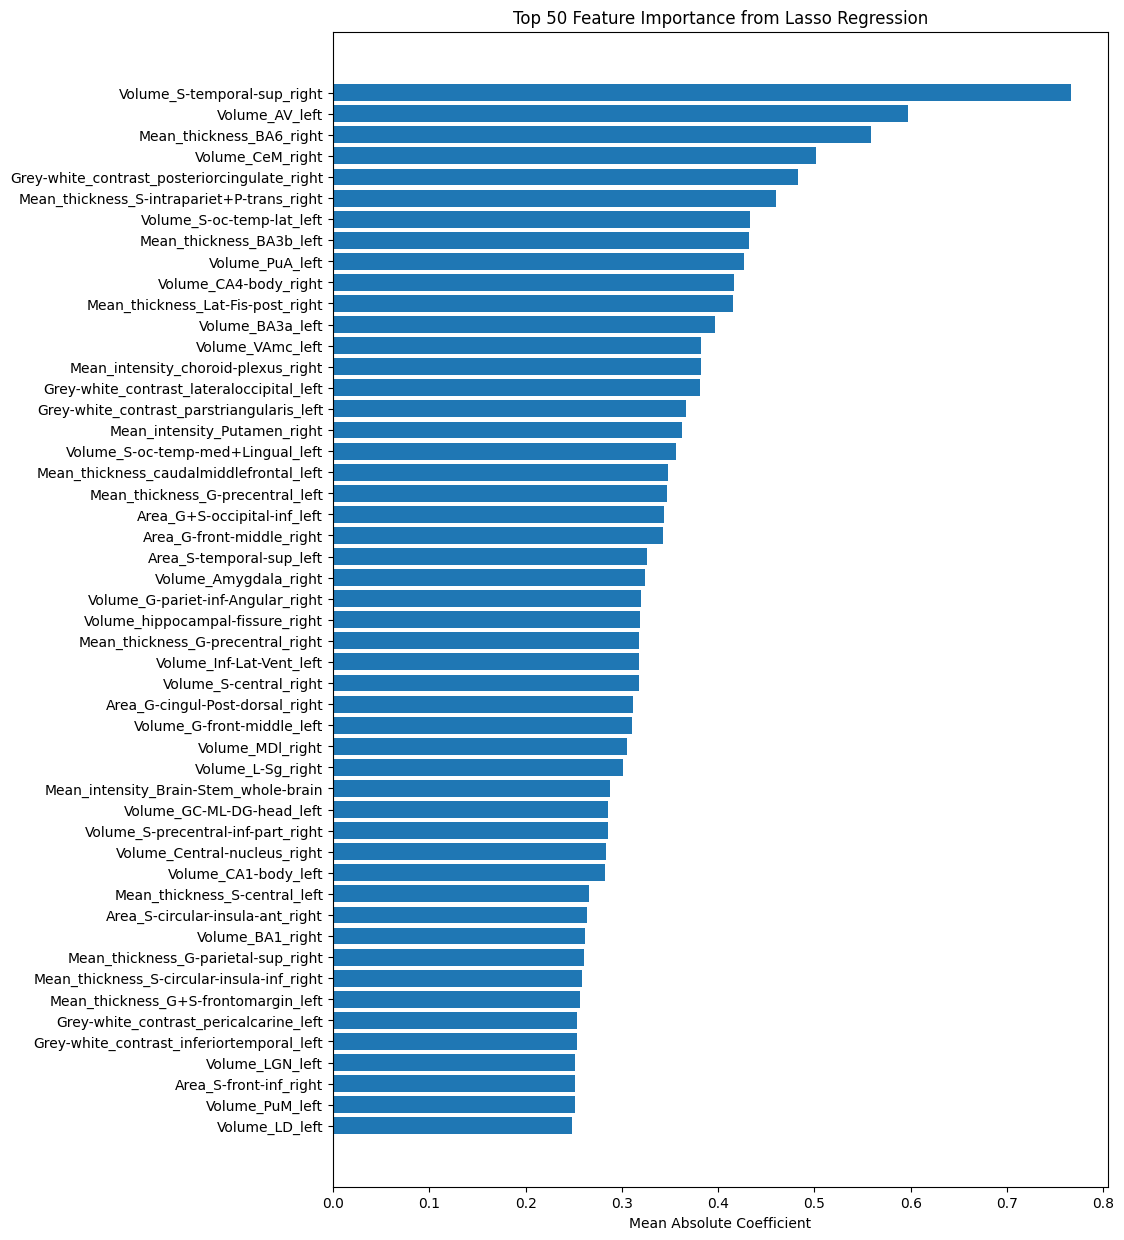

In [50]:
# plot most 50 important features
plt.figure(figsize=(10, 15))
plt.barh(feature_importance_lasso["feature"][:50], feature_importance_lasso["importance"][:50])
plt.xlabel("Mean Absolute Coefficient")
plt.title("Top 50 Feature Importance from Lasso Regression")
plt.gca().invert_yaxis()
plt.show()

In [47]:
# create 10 models with different random seeds 
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np  

seeds = np.arange(50)
results_ridge = []
for seed in seeds:
    X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_SCZ", testsize = 0.2, seed=seed)
    lasso = Ridge(alpha=1000.0  , random_state=seed, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred_train = lasso.predict(X_train)
    y_pred_test = lasso.predict(X_test)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    # extract the beta coefficients
    beta = lasso.coef_
    results_ridge.append((seed, train_mse, test_mse, train_r2, test_r2, beta))

In [48]:
# rank the most important features by the mean absolute value of their coefficients across the 10 models
import pandas as pd
columns = df.columns[:-2]  # all columns except the target
feature_importance_ridge = pd.DataFrame({
    "feature": columns,
    "importance": np.mean([np.abs(result[5]) for result in results_ridge], axis=0)
}).sort_values(by="importance", ascending=False)

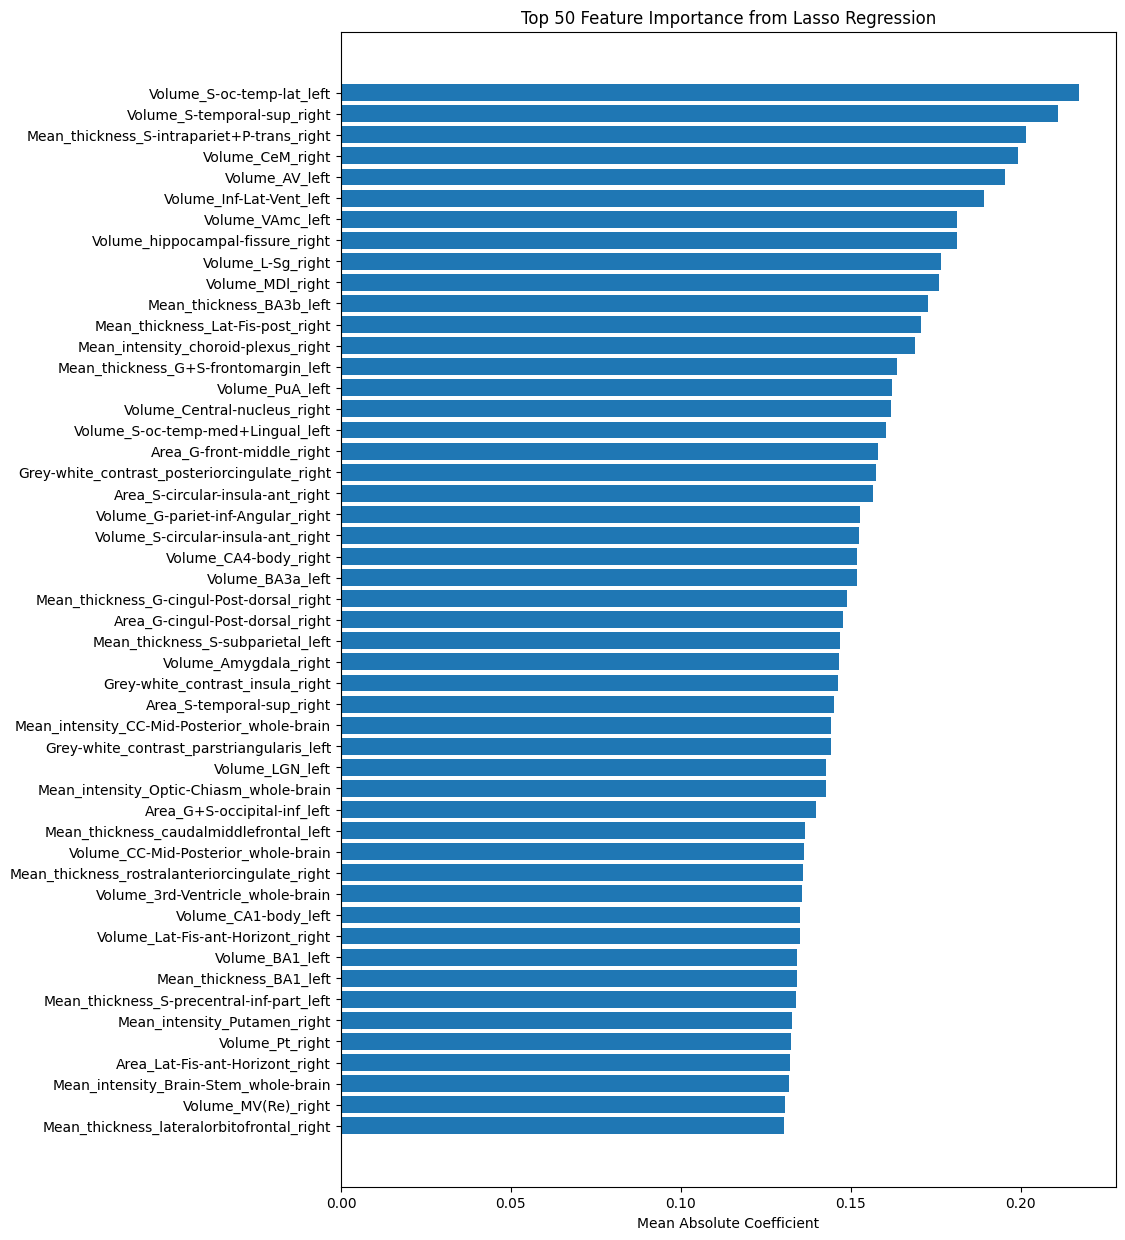

In [52]:
# plot most 50 important features
plt.figure(figsize=(10, 15))
plt.barh(feature_importance_ridge["feature"][:50], feature_importance_ridge["importance"][:50])
plt.xlabel("Mean Absolute Coefficient")
plt.title("Top 50 Feature Importance from Lasso Regression")
plt.gca().invert_yaxis()
plt.show()

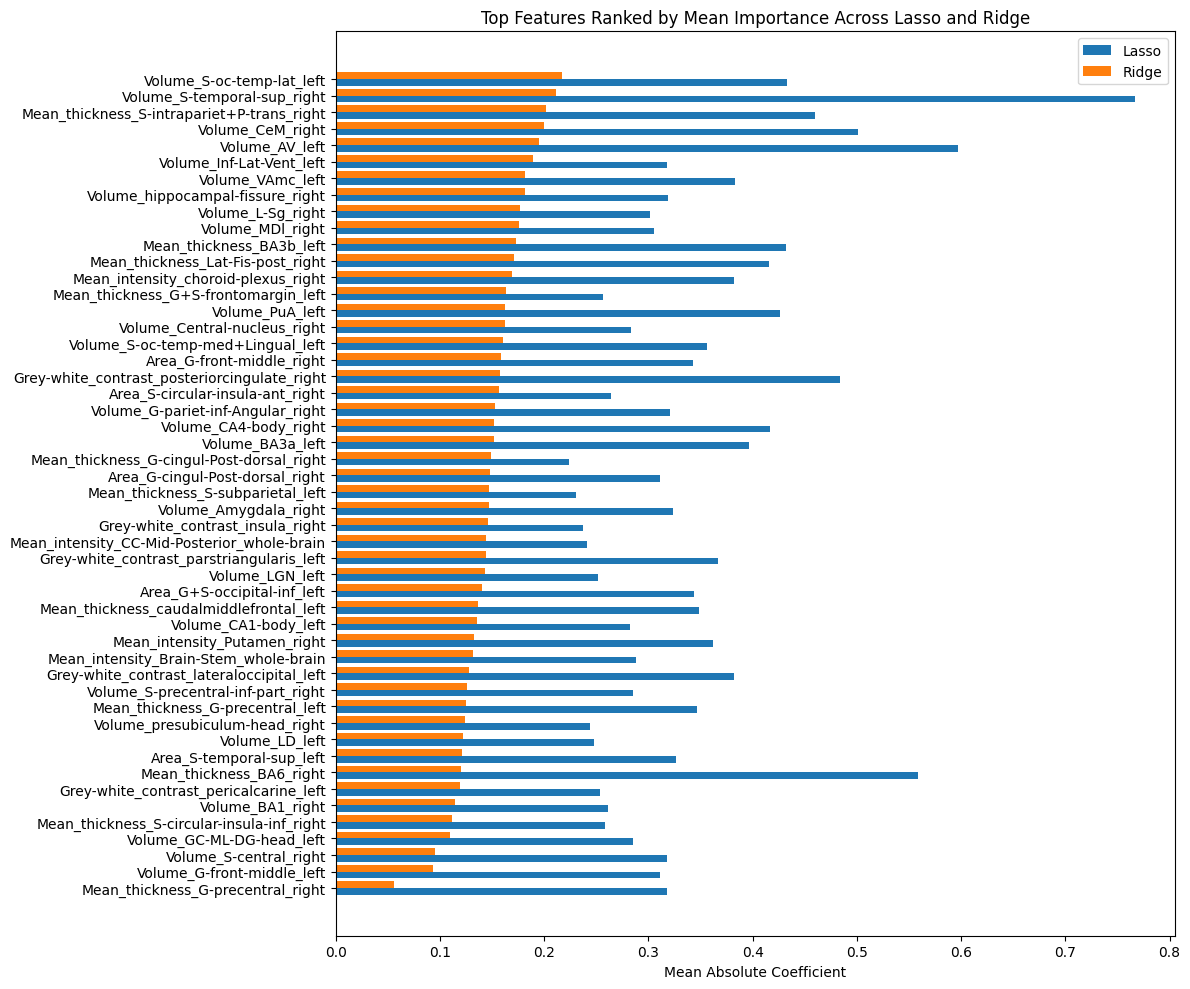

,feature,lasso_importance,ridge_importance,mean_importance
879,Volume_S-temporal-sup_right,0.766469,0.210973,0.488721
599,Volume_AV_left,0.597262,0.195420,0.396341
658,Volume_CeM_right,0.501384,0.199391,0.350387
368,Mean_thickness_BA6_right,0.558428,0.119762,0.339095
484,Mean_thickness_S-intrapariet+P-trans_right,0.459775,0.201649,0.330712
850,Volume_S-oc-temp-lat_left,0.432790,0.217232,0.325011
289,Grey-white_contrast_posteriorcingulate_right,0.483411,0.157361,0.320386
357,Mean_thickness_BA3b_left,0.431928,0.172694,0.302311
810,Volume_PuA_left,0.426672,0.162117,0.294394
452,Mean_thickness_Lat-Fis-post_right,0.415355,0.170592,0.292973


In [56]:
# merge lasso and ridge importances, rank by mean score, and plot both
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged_importance = (
    feature_importance_lasso.rename(columns={"importance": "lasso_importance"})
    .merge(
        feature_importance_ridge.rename(columns={"importance": "ridge_importance"}),
        on="feature",
        how="outer",
    )
    .fillna(0)
)

merged_importance["mean_importance"] = merged_importance[["lasso_importance", "ridge_importance"]].mean(axis=1)
merged_importance = merged_importance.sort_values("mean_importance", ascending=False)

best_features = merged_importance.head(50).sort_values("ridge_importance", ascending=True)

y = np.arange(len(best_features))
plt.figure(figsize=(12, 10))
plt.barh(y - 0.2, best_features["lasso_importance"], height=0.4, label="Lasso")
plt.barh(y + 0.2, best_features["ridge_importance"], height=0.4, label="Ridge")
plt.yticks(y, best_features["feature"])
plt.xlabel("Mean Absolute Coefficient")
plt.title("Top Features Ranked by Mean Importance Across Lasso and Ridge")
plt.legend()
plt.tight_layout()
plt.show()

merged_importance.head(10)


In [ ]:
# plot based on lasso importance only
